# nshap

In [36]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ast

In [37]:
df = pd.read_csv(r"C:\Users\tbezdan\Desktop\crAIRsis datasets\EU_cls\data\nshap\filename_covid_filter_col_None_filter_val_None_target_CRAI_ml_model_ExtraTreesModel_mh_algo_SCA_banzhaf_interaction_index_values.csv")

In [38]:
feature_names = pd.read_csv(r"C:\Users\tbezdan\Desktop\crAIRsis datasets\EU_cls\data\nshap\filename_covid_filter_col_None_filter_val_None_target_CRAI_ml_model_ExtraTreesModel_mh_algo_SCA_feature_names.csv")
feature_names = list(feature_names.columns)

In [39]:
instance_id = 383
df = df[df['id']==instance_id]

In [40]:
df = df.drop('id', axis=1)

In [41]:
# Convert each entry in the interaction column to a tuple
df['interaction'] = df['interaction'].apply(ast.literal_eval)

In [29]:
# Initialize dictionaries to hold positive and negative contributions
positive_contributions = {order: np.zeros(len(feature_names)) for order in range(1, df['order'].max() + 1)}
negative_contributions = {order: np.zeros(len(feature_names)) for order in range(1, df['order'].max() + 1)}
# Aggregate contributions
for _, row in df.iterrows():
    interaction = row['interaction']  
    value = row['value']
    order = row['order']
    for feature in interaction:
        if value > 0:
            positive_contributions[order][feature] += value / order
        else:
            negative_contributions[order][feature] += value / order


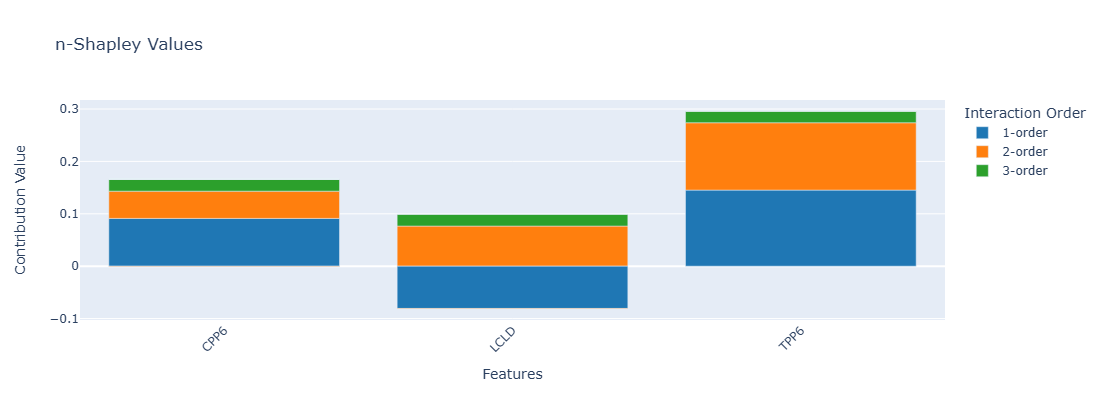

In [42]:

colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"
]


fig = go.Figure()


for order, contributions in positive_contributions.items():
    fig.add_trace(go.Bar(
        x=feature_names,
        y=contributions,
        name=f'{order}-order',
        marker_color=colors[order - 1],
    ))


for order, contributions in negative_contributions.items():
    fig.add_trace(go.Bar(
        x=feature_names,
        y=contributions,
        name=f'{order}-order',
        marker_color=colors[order - 1],
        showlegend=False 
    ))


fig.update_layout(
    barmode='relative',
    title='n-Shapley Values',
    xaxis=dict(title='Features', tickangle=-45),
    yaxis=dict(title='Contribution Value'),
    legend=dict(title='Interaction Order'),
    height=400,
    width=600
)

fig.show()

# gshap

In [43]:
import pandas as pd
import numpy as np
import plotly.express as px

In [44]:

df = pd.read_csv(r"C:\Users\tbezdan\Desktop\crAIRsis datasets\reg_test\data\gshap\filename_ca_housing_filter_col_None_filter_val_None_target_target_ml_model_LGBMModel_mh_algo_SCA_gshap_values.csv")

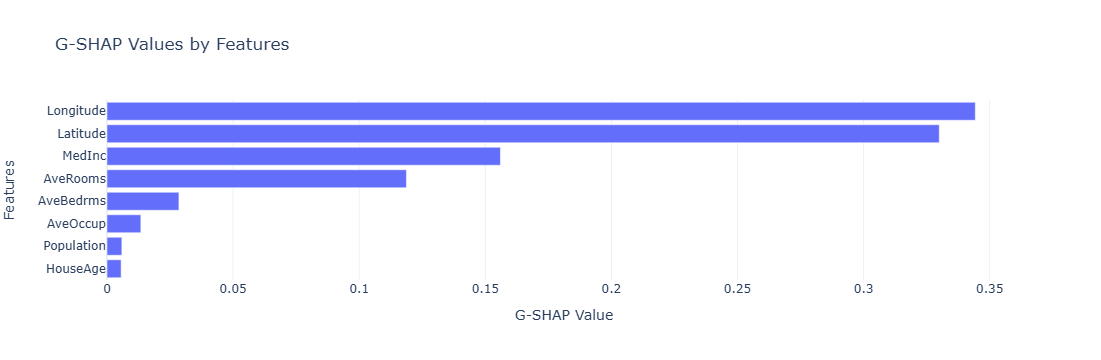

In [45]:


fig = px.bar(
    df,
    x='gshap',
    y='features',
    orientation='h',  # Horizontal bar plot
    title="G-SHAP Values by Features",
    labels={'G-SHAP': 'G-SHAP Value', 'Features': 'Features'},  # Axis labels
)


fig.update_layout(
    xaxis_title="G-SHAP Value",
    yaxis_title="Features",
    yaxis=dict(categoryorder='total ascending'),  
    template="plotly_white"  
)


fig.show()
